In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
df = pd.read_csv('/content/skewed_dataset_300_rows.csv')

In [ ]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [ ]:
cols = X.columns[:2]

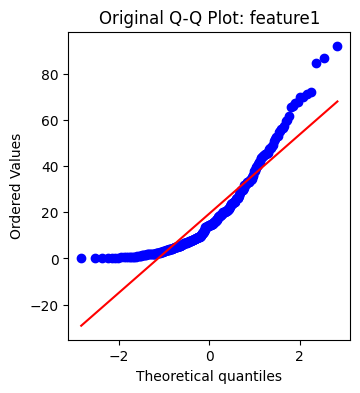

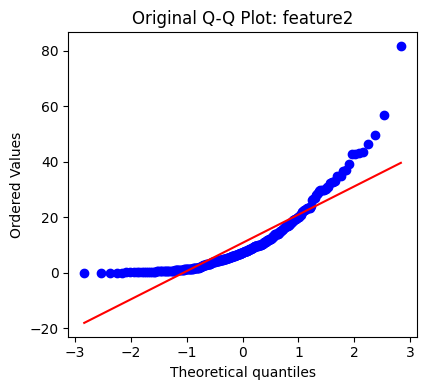

In [ ]:
for i, col in enumerate(X.columns):
    plt.figure(figsize=(8,4))
    plt.subplot(1, 2, i+1)
    stats.probplot(X[col], dist="norm", plot=plt)
    plt.title(f"Original Q-Q Plot: {col}")

plt.tight_layout()
plt.show()

In [ ]:
X_boxcox = X.copy()

In [ ]:
X_boxcox = X_boxcox + 1 - X_boxcox.min()

pt_boxcox = PowerTransformer(method='box-cox')
X_boxcox_transformed = pt_boxcox.fit_transform(X_boxcox)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_boxcox_transformed, y, test_size=0.2, random_state=42
)

In [ ]:
model_boxcox = LogisticRegression(max_iter=1000)
model_boxcox.fit(X_train, y_train)

y_pred = model_boxcox.predict(X_test)
print("Box-Cox Accuracy:", accuracy_score(y_test, y_pred))

Box-Cox Accuracy: 0.8166666666666667


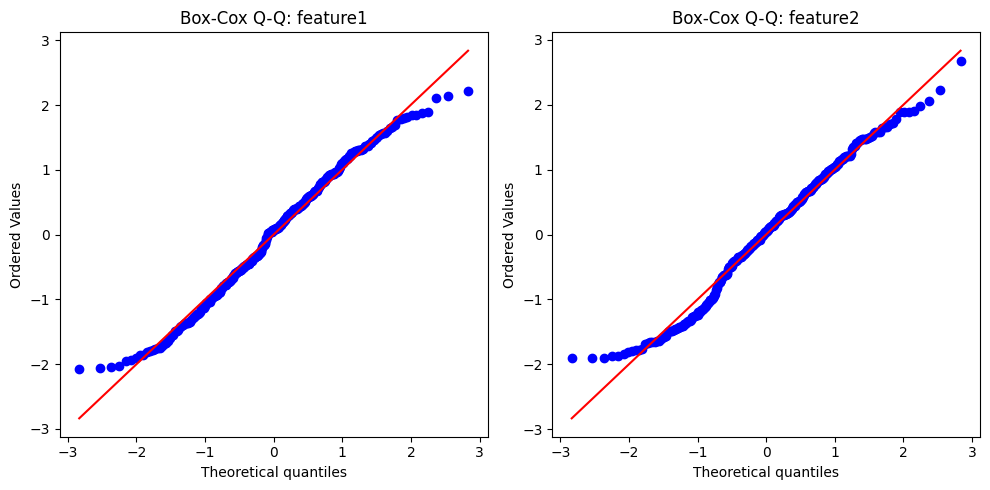

In [ ]:
plt.figure(figsize=(10, 5))

for i in range(2):
    plt.subplot(1, 2, i+1)
    stats.probplot(X_boxcox_transformed[:, i], dist="norm", plot=plt)
    plt.title(f"Box-Cox Q-Q: {cols[i]}")

plt.tight_layout()
plt.show()

In [ ]:
pt_yeo = PowerTransformer(method='yeo-johnson')
X_yeo = pt_yeo.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_yeo, y, test_size=0.2, random_state=42
)

In [ ]:
model_yeo = LogisticRegression(max_iter=1000)
model_yeo.fit(X_train, y_train)

y_pred = model_yeo.predict(X_test)
print("Yeo-Johnson Accuracy:", accuracy_score(y_test, y_pred))

Yeo-Johnson Accuracy: 0.8166666666666667


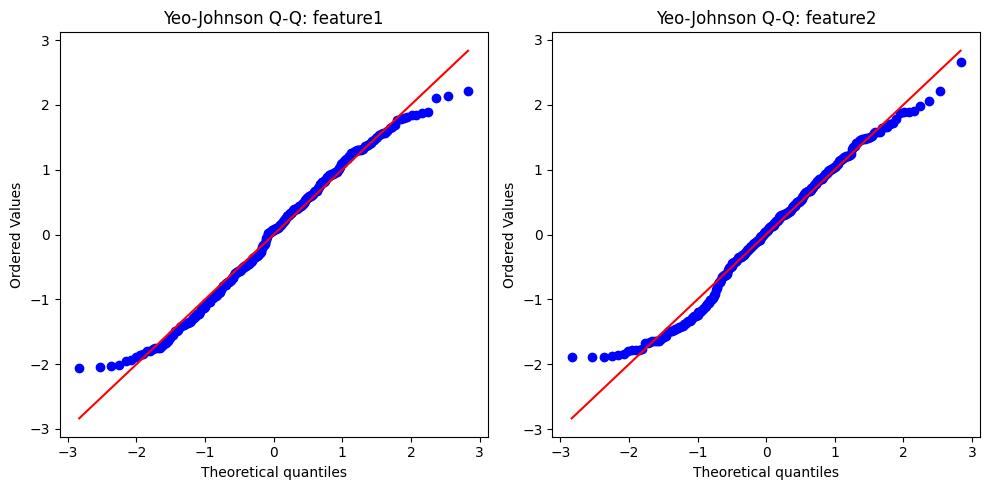

In [ ]:
plt.figure(figsize=(10, 5))

for i in range(2):
    plt.subplot(1, 2, i+1)
    stats.probplot(X_yeo[:, i], dist="norm", plot=plt)
    plt.title(f"Yeo-Johnson Q-Q: {cols[i]}")

plt.tight_layout()
plt.show()